In [1]:
!pip install -q "protobuf==3.20.3" keras-flops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 6.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
ray 2.52.1 requires click!=8.3.*,>=7.0, but you have click 8.3.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.

In [2]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from tensorflow.keras import layers, models, optimizers, losses, regularizers
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

# Seed for reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"TensorFlow Version: {tf.__version__}")
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
if gpu_devices:
    print(f"GPU Detected: {gpu_devices}")
else:
    print("No GPU detected. Running on CPU.")

2026-01-21 14:09:16.141987: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769004556.312061      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769004556.363845      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769004556.769127      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769004556.769165      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769004556.769168      55 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
GPU Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# --- DATASET CONFIGURATION (Paper Section IV.B: 70% Train, 10% Val, 20% Test) ---

CSV_PATH = "/kaggle/input/nuero-dataset-balanced/nuero_dataset_balanced/image_labels_balanced.csv"
IMAGES_DIR = "/kaggle/input/nuero-dataset-balanced/nuero_dataset_balanced/images"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

df = pd.read_csv(CSV_PATH)
train_val_df, test_df = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=SEED)
train_df, val_df = train_test_split(train_val_df, test_size=0.125, stratify=train_val_df['label'], random_state=SEED) 

print(f"Training Samples: {len(train_df)} (Approx 70%)")
print(f"Validation Samples: {len(val_df)} (Approx 10%)")
print(f"Testing Samples: {len(test_df)} (Approx 20%)")

Training Samples: 4996 (Approx 70%)
Validation Samples: 714 (Approx 10%)
Testing Samples: 1428 (Approx 20%)


In [4]:
# --- DATA GENERATORS ---

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGES_DIR,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=IMAGES_DIR,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=IMAGES_DIR,
    x_col='filename',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = len(train_gen.class_indices)
CLASS_LABELS = list(train_gen.class_indices.keys())

Found 4996 validated image filenames belonging to 9 classes.
Found 714 validated image filenames belonging to 9 classes.
Found 1428 validated image filenames belonging to 9 classes.


In [5]:
# --- TEACHER MODEL: MobileNetV1 (Paper Section III.A) ---

def build_teacher_model(num_classes):
    base = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dense(1024, activation='relu')(x) 
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs=base.input, outputs=outputs, name="Teacher_MobileNet")

teacher_model = build_teacher_model(NUM_CLASSES)
teacher_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), 
                      loss='categorical_crossentropy', 
                      metrics=['accuracy'])

I0000 00:00:1769004576.866918      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
# --- STUDENT MODEL: KDLight (Paper Table I) ---

def build_kdlight_student(num_classes):
    inputs = layers.Input(shape=(224, 224, 3))
    
    # Conv2d 1st & 2nd Block
    x = layers.Conv2D(32, (3, 3), padding='valid', activation='relu', name="Conv2d_1st")(inputs)
    x = layers.MaxPooling2D((2, 2), name="Max_Pooling_1")(x)
    
    x = layers.Conv2D(32, (3, 3), padding='valid', activation='relu', name="Conv2d_2nd")(x)
    x = layers.MaxPooling2D((2, 2), name="Max_Pooling_2")(x)
    x = layers.Dropout(0.25)(x)
    
    # Conv2d 3rd & 4th Block
    x = layers.Conv2D(64, (3, 3), padding='valid', activation='relu', name="Conv2d_3rd")(x)
    x = layers.Conv2D(64, (3, 3), padding='valid', activation='relu', name="Conv2d_4th")(x)
    x = layers.MaxPooling2D((2, 2), name="Max_Pooling_3")(x)
    x = layers.Dropout(0.25)(x)
    
    # Conv2d 5th & 6th Block
    x = layers.Conv2D(128, (3, 3), padding='valid', activation='relu', name="Conv2d_5th")(x)
    x = layers.Conv2D(128, (3, 3), padding='valid', activation='relu', name="Conv2d_6th")(x)
    x = layers.MaxPooling2D((2, 2), name="Max_Pooling_4")(x)
    x = layers.Dropout(0.25)(x)
    
    # Conv2d 7th & 8th Block (Channel Reduction 128 -> 16)
    x = layers.Conv2D(16, (3, 3), padding='same', activation='relu', name="Conv2d_7th")(x)
    x = layers.Conv2D(16, (3, 3), padding='same', activation='relu', name="Conv2d_8th")(x)
    x = layers.MaxPooling2D((2, 2), padding='same', name="Max_Pooling_5")(x)
    
    # Classification Head
    x = layers.Flatten(name="Flatten")(x)
    x = layers.Dense(128, activation='relu', name="Dense_128")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Dense(64, activation='relu', name="Dense_64")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax', name="Output")(x)
    
    return models.Model(inputs=inputs, outputs=outputs, name="KDLight_Student")

student_model_scratch = build_kdlight_student(NUM_CLASSES) # For comparison "Before KD"
student_model_kd = build_kdlight_student(NUM_CLASSES)      # For "After KD"

In [7]:
# --- KNOWLEDGE DISTILLATION FRAMEWORK (Paper Section III.A: Eq 1-3) ---

class KDLight_Distiller(models.Model):
    def __init__(self, student, teacher):
        super(KDLight_Distiller, self).__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.5, beta=0.5, temperature=3):
        super(KDLight_Distiller, self).compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.beta = beta
        self.temperature = temperature

    def train_step(self, data):
        x, y = data
        
        # Teacher Forward Pass (Training=False)
        teacher_predictions = self.teacher(x, training=False)
        
        with tf.GradientTape() as tape:
            # Student Forward Pass
            student_predictions = self.student(x, training=True)
            
            # 1. Hard Loss (Cross Entropy)
            student_loss = self.student_loss_fn(y, student_predictions)
            
            # 2. Soft Loss (Distillation) with Temperature
            teacher_soft = tf.nn.softmax(teacher_predictions / self.temperature, axis=1)
            student_soft = tf.nn.softmax(student_predictions / self.temperature, axis=1)
            distillation_loss = self.distillation_loss_fn(teacher_soft, student_soft) * (self.temperature ** 2)
            
            # Total Loss
            loss = self.alpha * student_loss + self.beta * distillation_loss

        # Backpropagation
        gradients = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))
        
        self.compiled_metrics.update_state(y, student_predictions)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss, "distill_loss": distillation_loss, "total_loss": loss})
        return results

    def test_step(self, data):
        x, y = data
        y_pred = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_pred)
        self.compiled_metrics.update_state(y, y_pred)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss})
        return results

In [8]:
# --- EXPERIMENT 1: TRAIN TEACHER (MobileNet) ---

print("=== Training Teacher (MobileNet) ===")
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint('teacher_mobilenet.keras', save_best_only=True)
]

start_time = time.time()
teacher_history = teacher_model.fit(
    train_gen,
    epochs=20, # Paper specifies 20 epochs
    validation_data=val_gen,
    callbacks=callbacks
)
teacher_train_time = time.time() - start_time
print(f"Teacher Training Time: {teacher_train_time:.2f}s")

=== Training Teacher (MobileNet) ===


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1769004598.199950     126 service.cc:152] XLA service 0x7ef77c0035c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769004598.199987     126 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769004600.296130     126 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-21 14:10:07.643305: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-21 14:10:07.842980: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1769004613.721089     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proc

157/157 ━━━━━━━━━━━━━━━━━━━━ 112s 486ms/step - accuracy: 0.8004 - loss: 0.6485 - val_accuracy: 0.8922 - val_loss: 0.4401
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 232ms/step - accuracy: 0.9524 - loss: 0.1389 - val_accuracy: 0.8655 - val_loss: 0.4569
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 239ms/step - accuracy: 0.9591 - loss: 0.1316 - val_accuracy: 0.8908 - val_loss: 0.4003
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 231ms/step - accuracy: 0.9522 - loss: 0.1449 - val_accuracy: 0.8782 - val_loss: 0.4240
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 235ms/step - accuracy: 0.9706 - loss: 0.0881 - val_accuracy: 0.9020 - val_loss: 0.3443
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 236ms/step - accuracy: 0.9805 - loss: 0.0551 - val_accuracy: 0.9608 - val_loss: 0.1289
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 240ms/step - accuracy: 0.9843 - loss: 0.0507 - val_accuracy: 0.9678 - val_loss: 0.1030
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 232ms/step - accuracy: 0.9910 - loss: 0.0340 - va

In [9]:
# --- EXPERIMENT 2: TRAIN STUDENT (KDLight) via DISTILLATION ---

print("=== Training KDLight Student via Distillation ===")

distiller = KDLight_Distiller(student=student_model_kd, teacher=teacher_model)
distiller.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    metrics=['accuracy'],
    student_loss_fn=losses.CategoricalCrossentropy(from_logits=False),
    distillation_loss_fn=losses.KLDivergence(),
    alpha=0.5,
    beta=0.5,
    temperature=5
)

kd_history = distiller.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen
)
student_model_kd.save('kdlight_student.keras')

=== Training KDLight Student via Distillation ===
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:646: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(


157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 296ms/step - accuracy: 0.3258 - distill_loss: 0.0442 - loss: 0.1111 - student_loss: 1.6471 - total_loss: 0.8456 - val_loss: 0.1111 - val_student_loss: 1.3394
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 240ms/step - accuracy: 0.5346 - distill_loss: 0.0348 - loss: 0.1111 - student_loss: 1.1316 - total_loss: 0.5832 - val_loss: 0.1111 - val_student_loss: 1.0101
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 237ms/step - accuracy: 0.6017 - distill_loss: 0.0303 - loss: 0.1111 - student_loss: 0.9448 - total_loss: 0.4876 - val_loss: 0.1111 - val_student_loss: 0.8739
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 229ms/step - accuracy: 0.6349 - distill_loss: 0.0284 - loss: 0.1111 - student_loss: 0.8600 - total_loss: 0.4442 - val_loss: 0.1111 - val_student_loss: 0.7904
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 228ms/step - accuracy: 0.6697 - distill_loss: 0.0261 - loss: 0.1111 - student_loss: 0.7827 - total_loss: 0.4044 - val_loss: 0.1111 - val_student_loss: 1.1081
E

In [10]:
# --- EVALUATION METRICS & COMPLEXITY ANALYSIS (Table V) ---

def get_flops(model):
    # Calculate FLOPs using TensorFlow Profiler
    forward_pass = tf.function(model.call, input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:], dtype=tf.float32)])
    graph_info = profile(forward_pass.get_concrete_function().graph, options=ProfileOptionBuilder.float_operation())
    return graph_info.total_float_ops

def get_model_size(file_path):
    return os.path.getsize(file_path) / (1024 * 1024)

def measure_inference_time(model, sample_batch):
    start = time.time()
    model.predict(sample_batch, verbose=0)
    end = time.time()
    return (end - start)

# Generate Metrics
sample_batch, _ = next(iter(test_gen))
teacher_flops = get_flops(teacher_model)
student_flops = get_flops(student_model_kd)

teacher_size = get_model_size('teacher_mobilenet.keras')
student_size = get_model_size('kdlight_student.keras')

teacher_inf_time = measure_inference_time(teacher_model, sample_batch)
student_inf_time = measure_inference_time(student_model_kd, sample_batch)

complexity_df = pd.DataFrame({
    'Model': ['Teacher (MobileNet)', 'Student (KDLight)'],
    'Memory (MB)': [f"{teacher_size:.2f}", f"{student_size:.2f}"],
    'FLOPs': [f"{teacher_flops:,}", f"{student_flops:,}"],
    'Test Time (sec)': [f"{teacher_inf_time:.4f}", f"{student_inf_time:.4f}"]
})
print("\n=== Table V: Complexity Analysis ===")
print(complexity_df)

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model g

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


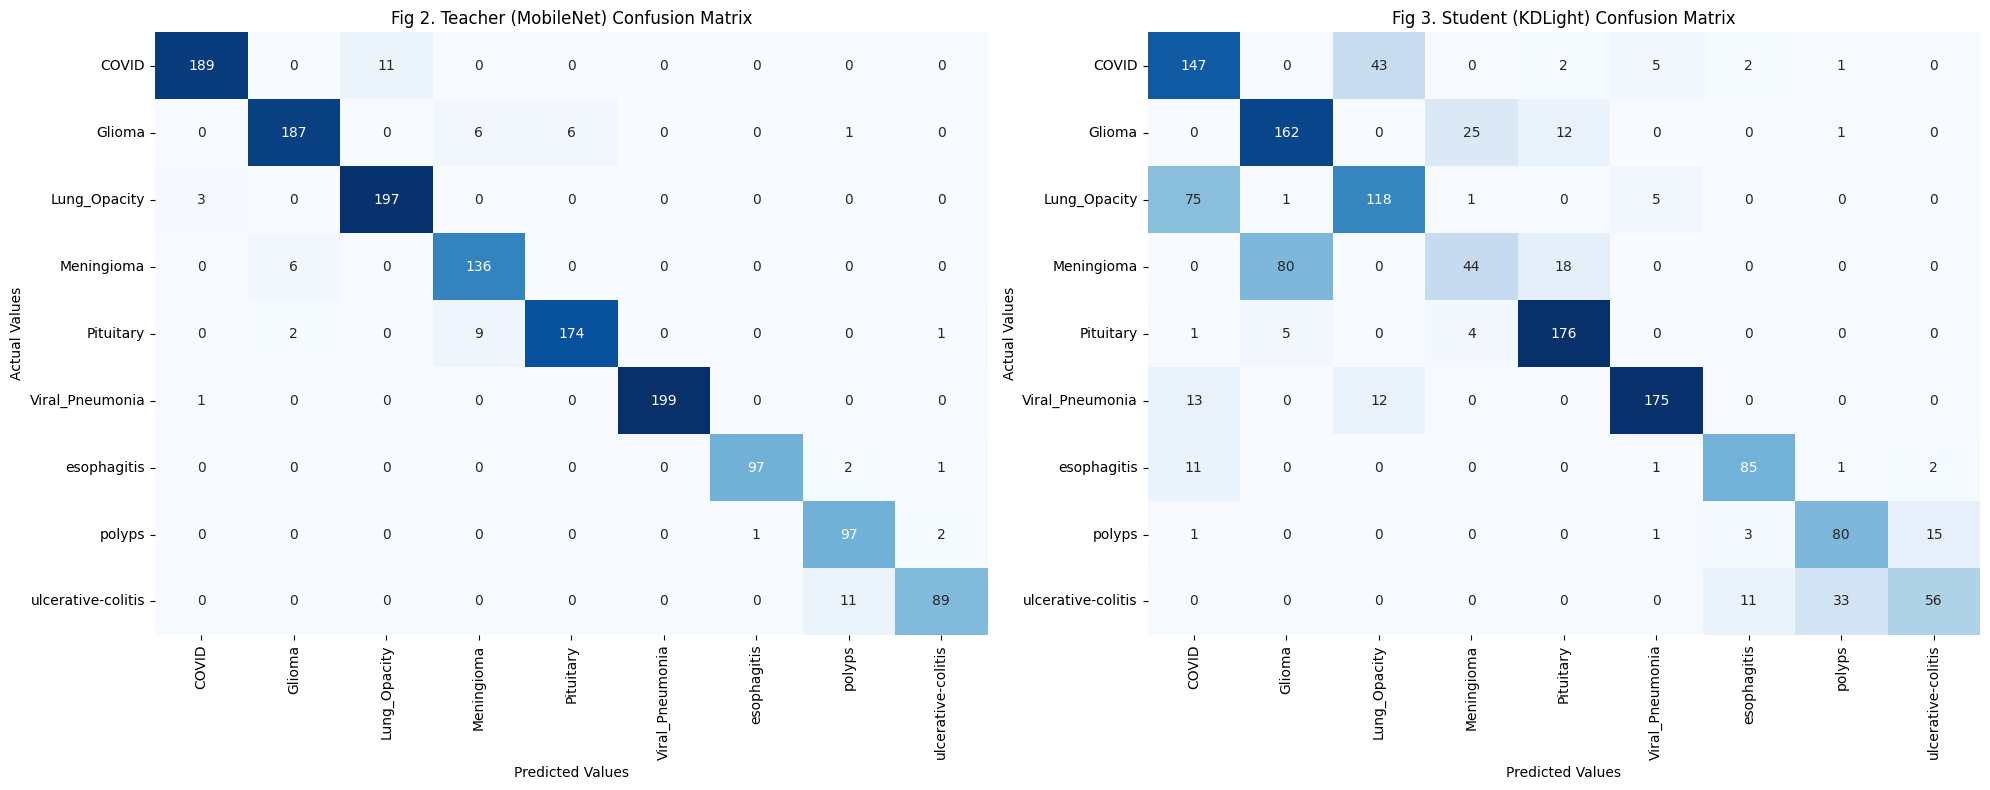

In [11]:
# --- PERFORMANCE VISUALIZATIONS ---

def plot_confusion_matrix(model, title, ax):
    test_gen.reset()
    y_pred_prob = model.predict(test_gen, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = test_gen.classes
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_ylabel('Actual Values')
    ax.set_xlabel('Predicted Values')
    return y_true, y_pred_prob

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
y_true, y_pred_teacher = plot_confusion_matrix(teacher_model, "Fig 2. Teacher (MobileNet) Confusion Matrix", axes[0])
y_true, y_pred_student = plot_confusion_matrix(student_model_kd, "Fig 3. Student (KDLight) Confusion Matrix", axes[1])
plt.tight_layout()
plt.show()

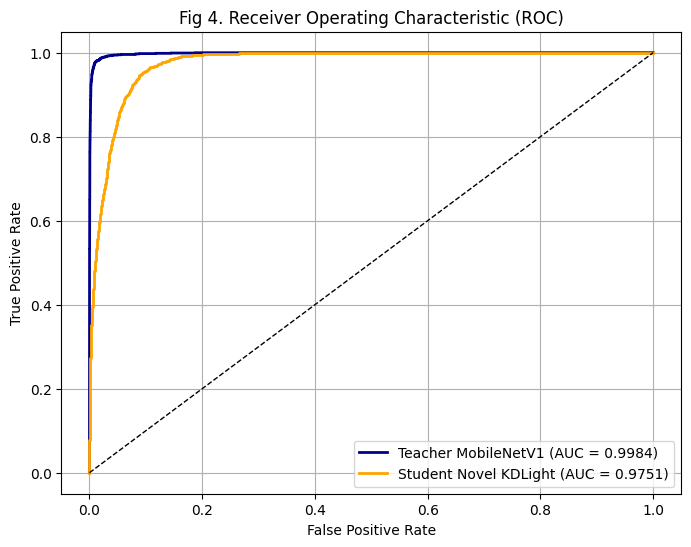

In [12]:
# --- ROC-AUC CURVE (Figure 4) ---

def plot_roc_auc(y_true, y_pred_teacher, y_pred_student, n_classes):
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    # Compute Micro-Average ROC
    fpr_t, tpr_t, _ = roc_curve(y_true_bin.ravel(), y_pred_teacher.ravel())
    auc_t = auc(fpr_t, tpr_t)
    
    fpr_s, tpr_s, _ = roc_curve(y_true_bin.ravel(), y_pred_student.ravel())
    auc_s = auc(fpr_s, tpr_s)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_t, tpr_t, color='darkblue', linestyle='-', lw=2, label=f'Teacher MobileNetV1 (AUC = {auc_t:.4f})')
    plt.plot(fpr_s, tpr_s, color='orange', linestyle='-', lw=2, label=f'Student Novel KDLight (AUC = {auc_s:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Fig 4. Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

plot_roc_auc(y_true, y_pred_teacher, y_pred_student, NUM_CLASSES)

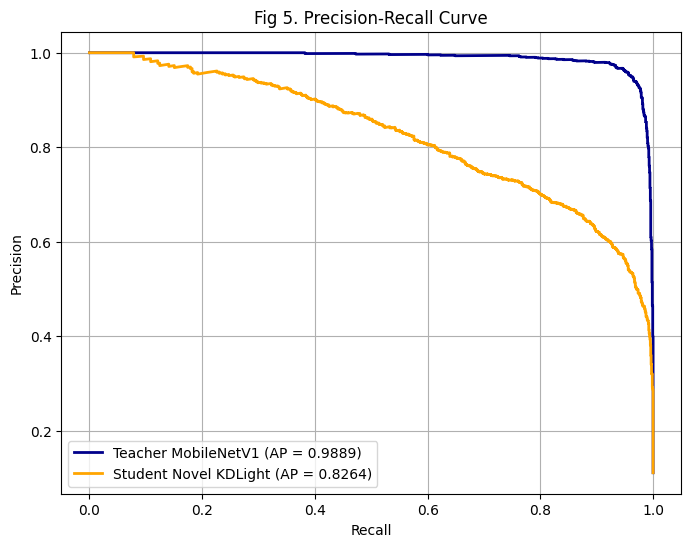

In [13]:
# --- PRECISION-RECALL CURVE (Figure 5) ---

def plot_pr_curve(y_true, y_pred_teacher, y_pred_student, n_classes):
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    # Micro-Average PR
    precision_t, recall_t, _ = precision_recall_curve(y_true_bin.ravel(), y_pred_teacher.ravel())
    ap_t = average_precision_score(y_true_bin, y_pred_teacher, average="micro")
    
    precision_s, recall_s, _ = precision_recall_curve(y_true_bin.ravel(), y_pred_student.ravel())
    ap_s = average_precision_score(y_true_bin, y_pred_student, average="micro")
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall_t, precision_t, color='darkblue', lw=2, label=f'Teacher MobileNetV1 (AP = {ap_t:.4f})')
    plt.plot(recall_s, precision_s, color='orange', lw=2, label=f'Student Novel KDLight (AP = {ap_s:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Fig 5. Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

plot_pr_curve(y_true, y_pred_teacher, y_pred_student, NUM_CLASSES)

In [14]:
# --- CLASS-WISE PERFORMANCE (Table III) ---

def generate_performance_table(y_true, y_pred_prob, model_name):
    y_pred = np.argmax(y_pred_prob, axis=1)
    report = classification_report(y_true, y_pred, target_names=CLASS_LABELS, output_dict=True)
    
    data = []
    for cls in CLASS_LABELS:
        row = {
            'Model': model_name,
            'Class': cls,
            'Precision': f"{report[cls]['precision']:.2f}",
            'Recall': f"{report[cls]['recall']:.2f}",
            'F1-Score': f"{report[cls]['f1-score']:.2f}"
        }
        data.append(row)
    
    # Add Overall Accuracy row
    data.append({
        'Model': model_name, 
        'Class': 'OVERALL ACCURACY', 
        'Precision': '-', 
        'Recall': '-', 
        'F1-Score': f"{report['accuracy']:.2%}"
    })
    
    return pd.DataFrame(data)

df_teacher = generate_performance_table(y_true, y_pred_teacher, "Teacher (MobileNet)")
df_student = generate_performance_table(y_true, y_pred_student, "Student (KDLight)")

print("\n=== Table III: Class-Wise Performance Evaluation ===")
print(pd.concat([df_teacher, df_student], ignore_index=True))


=== Table III: Class-Wise Performance Evaluation ===
                  Model               Class Precision Recall F1-Score
0   Teacher (MobileNet)               COVID      0.98   0.94     0.96
1   Teacher (MobileNet)              Glioma      0.96   0.94     0.95
2   Teacher (MobileNet)        Lung_Opacity      0.95   0.98     0.97
3   Teacher (MobileNet)          Meningioma      0.90   0.96     0.93
4   Teacher (MobileNet)           Pituitary      0.97   0.94     0.95
5   Teacher (MobileNet)     Viral_Pneumonia      1.00   0.99     1.00
6   Teacher (MobileNet)         esophagitis      0.99   0.97     0.98
7   Teacher (MobileNet)              polyps      0.87   0.97     0.92
8   Teacher (MobileNet)  ulcerative-colitis      0.96   0.89     0.92
9   Teacher (MobileNet)    OVERALL ACCURACY         -      -   95.59%
10    Student (KDLight)               COVID      0.59   0.73     0.66
11    Student (KDLight)              Glioma      0.65   0.81     0.72
12    Student (KDLight)        Lung_